In [2]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn

In [3]:
os.getcwd()

'd:\\work\\WBC_Segmentation\\WhileBloodCellClassification\\research'

In [4]:
os.chdir("..")

In [5]:
os.getcwd()

'd:\\work\\WBC_Segmentation\\WhileBloodCellClassification'

In [6]:
from WhiteBloodCellClassification.DomainAdaptation.DA_module import DomainAdaptationModule


trained_model_1 = DomainAdaptationModule()
trained_model_2 = DomainAdaptationModule()
trained_model_3 = DomainAdaptationModule()
trained_model_4 = DomainAdaptationModule()
path_model_1 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260526_215016\model_epoch_25.pth"
path_model_2 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260526_211124\model_epoch_20.pth"
path_model_3 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260403_233703\model_epoch_20.pth"
path_model_4 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260403_233703\model_epoch_25.pth"


# checkpoint_1 = torch.load(path_model_1, map_location="cpu")
# trained_model_1.load_state_dict(checkpoint_1['model_state_dict'])
# trained_model_1.load_state_dict(torch.load(path_model_1, map_location="cpu"))
# trained_model_1.eval()


# checkpoint_2 = torch.load(path_model_2, map_location="cpu")
# trained_model_2.load_state_dict(checkpoint_2['model_state_dict'])
# trained_model_2.load_state_dict(torch.load(path_model_2, map_location="cpu"))
# trained_model_2.eval()

# checkpoint_3 = torch.load(path_model_3, map_location="cpu")
# trained_model_3.load_state_dict(checkpoint_3['model_state_dict'])
trained_model_3.load_state_dict(torch.load(path_model_3, map_location="cpu"))
trained_model_3.eval()

# checkpoint_4 = torch.load(path_model_4, map_location="cpu")
# trained_model_4.load_state_dict(checkpoint_4['model_state_dict'])
trained_model_4.load_state_dict(torch.load(path_model_4, map_location="cpu"))
trained_model_4.eval()






d:\work\WBC_Segmentation\WhileBloodCellClassification\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\work\WBC_Segmentation\WhileBloodCellClassification\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DomainAdaptationModule(
  (pixel_encoder): PixelEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsamp

In [9]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [10]:
class JSTCDataset(Dataset):
    def __init__(self,root_dir,mask_dir,transform = transform, indices=None):
        self.mask_dir = os.path.join(root_dir, mask_dir)
        self.transforms = transform
        self.indices = indices
        # self.binary_dir = os.path.join(root_dir, binary_dir)
        self.images = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.bmp')])
        self.mask = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.png')])
        # self.binary = sorted([f for f in os.listdir(self.binary_dir) if f.endswith('.png')])
        assert len(self.images) == len(self.mask), "Số lượng image và mask không khớp!"

    
    def __len__(self):
        if self.indices is not None:
            return len(self.indices)
        return len(self.images)
    def __getitem__(self, idx):
        if self.indices is not None:
            idx = self.indices[idx]
        img_name = self.images[idx]
        mask_name = self.mask[idx]
        # binary_name = self.binary[idx]
        img_path = os.path.join(self.mask_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        # binary_path = os.path.join(self.binary_dir, binary_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        image = self.transforms(image)
        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        label_mask = np.zeros_like(mask)
        label_mask[mask == 255] = 2
        label_mask[mask == 128] = 1
        label_mask[mask == 0] = 0
        label_mask = torch.tensor(label_mask).long()
        # binary = cv2.imread(binary_path,0)
        # binary = cv2.resize(binary, (256, 256), interpolation=cv2.INTER_NEAREST)
        # label_binary = np.zeros_like(binary)
        # label_binary[binary == 255] = 1
        # label_binary[binary == 0] = 0
        # label_binary = torch.tensor(label_binary).long()
        return {
            "image": image,
            "mask": label_mask,
        }

In [11]:
root_dir = r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/SourceData"
mask_dir = r"Dataset"


In [12]:
np.random.seed(1)

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

fulldataset = JSTCDataset(root_dir, mask_dir, transform = transform)
num_samples = len(fulldataset)
indices = np.arange(num_samples)
np.random.shuffle(indices)
split = int(0.8 * num_samples)

train_indices = indices[:split]
val_indices = indices[split:]
train_dataset = JSTCDataset(root_dir, mask_dir, indices=train_indices, transform = transform)
val_dataset   = JSTCDataset(root_dir, mask_dir, indices=val_indices, transform = transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=40,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
for batch in train_loader:
    images_train = batch["image"]
    masks_train = batch["mask"]
    print(images_train.shape, masks_train.shape)
    break
for batch in val_loader:
    images_val = batch["image"]
    masks_val = batch["mask"]
    print(images_val.shape, masks_val.shape)
    break

torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256])
torch.Size([40, 3, 256, 256]) torch.Size([40, 256, 256])


In [ ]:
len(train_dataset)

320

In [ ]:
print(torch.unique(masks_train))
for k in range(3):
    ratio = (masks_train == k).float().mean()
    print(k, ratio.item())

tensor([0, 1, 2])
0 0.6932296752929688
1 0.17308425903320312
2 0.13368606567382812


In [ ]:
print(images_train.shape)

NameError: name 'images_train' is not defined

In [ ]:
mask = masks_train[0]
mask

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [ ]:
pred_image = trained_model_1(images_train)[0]
mask_pred = pred_image.argmax(dim=1)[0]
mask_pred

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [13]:
def compute_iou(pred, target, num_classes=3, ignore_index=None):
    """
    Tính Intersection over Union (IoU) cho từng class và mean IoU.
    Args:
        pred: (B, H, W) hoặc (H, W) – tensor chứa class index (0..num_classes-1)
        target: (B, H, W) hoặc (H, W) – ground truth
        num_classes: int    
        ignore_index: int (class bỏ qua, ví dụ background nếu muốn)
    Returns:
        ious: list IoU từng class (nan nếu class không xuất hiện)
        mean_iou: float (trung bình trên các class có union > 0)
    """
    if pred.dim() == 3:
        pred = pred.view(-1)
        target = target.view(-1)
    else:
        pred = pred.flatten()
        target = target.flatten()

    ious = []
    for cls in range(num_classes):
        if ignore_index is not None and cls == ignore_index:
            continue
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        if union == 0:
            iou = torch.tensor(float('nan'))
        else:
            iou = intersection / union
        ious.append(iou)
    mean_iou = torch.tensor([iou for iou in ious if not torch.isnan(iou)]).mean()
    return ious, mean_iou.item()


def compute_dice(pred, target, num_classes=3, smooth=1e-6):
    """
    Tính Dice coefficient (F1) cho từng class và mean Dice.
    Args:
        pred: (B, H, W) hoặc (H, W) – class indices
        target: (B, H, W) hoặc (H, W) – ground truth
        num_classes: int
        smooth: float – tránh chia 0
    Returns:
        dices: list Dice từng class
        mean_dice: float
    """
    if pred.dim() == 3:
        pred = pred.view(-1)
        target = target.view(-1)
    else:
        pred = pred.flatten()
        target = target.flatten()

    dices = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        total = pred_mask.sum() + target_mask.sum()
        if total == 0:
            dice = torch.tensor(float('nan'))
        else:
            dice = (2. * intersection + smooth) / (total + smooth)
        dices.append(dice)
    mean_dice = torch.tensor([d for d in dices if not torch.isnan(d)]).mean()
    return dices, mean_dice.item()

In [14]:
pred_image = trained_model_3(images_val)[0]
mask_pred = pred_image.argmax(dim=1)
ious, mean_iou = compute_iou(mask_pred, masks_val)
dices, mean_dice = compute_dice(mask_pred, masks_val)
print(f"IOU Loss : {mean_iou}")
print(f"DICE Loss : {mean_dice}")

: 

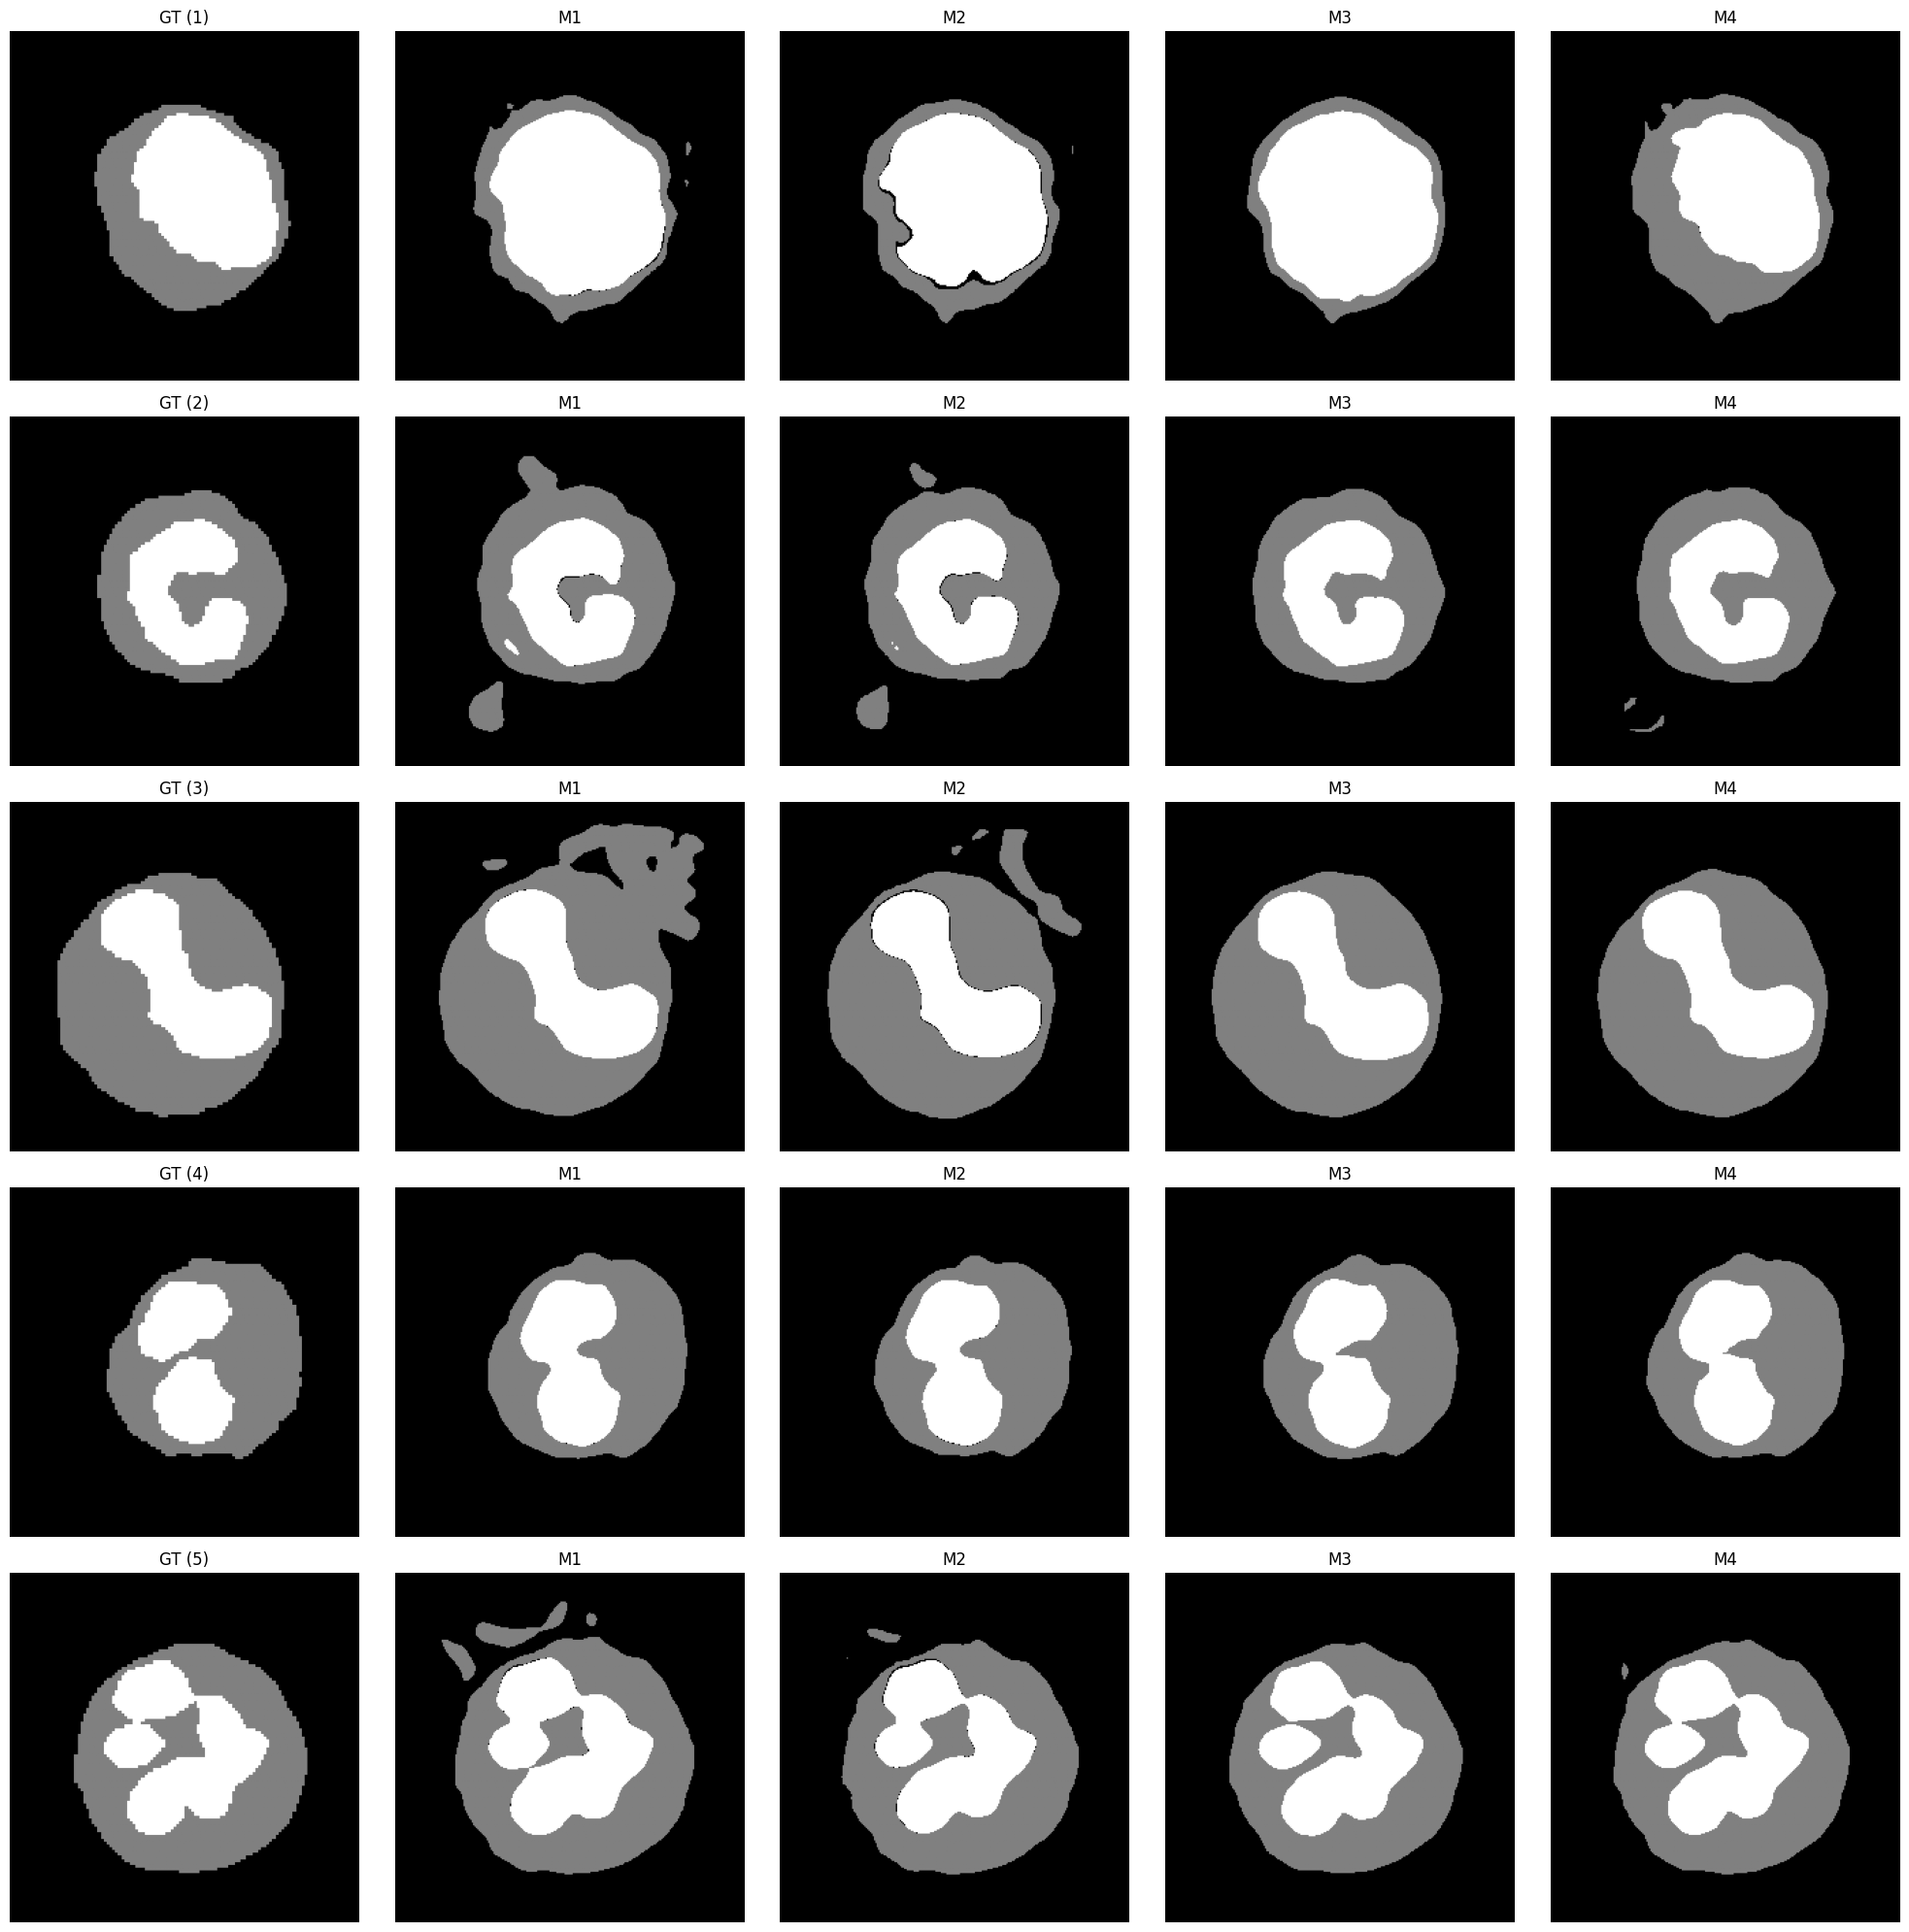

In [12]:
start_idx = 1
num_samples = 5 

models = [trained_model_1, trained_model_2, trained_model_3, trained_model_4]
titles = ["GT", "M1", "M2", "M3", "M4"]

fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4 * num_samples))

for i in range(num_samples):
    idx = start_idx + i

    image = images_val[idx].unsqueeze(0)
    mask_gt = masks_val[idx]   

    # ===== Ground truth =====
    mask_np_0 = mask_gt.cpu().numpy()
    mask_vis_0 = (mask_np_0 * (255 // 2)).astype(np.uint8)

    # plot GT
    axes[i, 0].imshow(mask_vis_0, cmap='gray')
    axes[i, 0].set_title(f"{titles[0]} ({idx})")
    axes[i, 0].axis('off')

    # ===== Models =====
    for j, model in enumerate(models):
        pred = model(image)[0].squeeze(0)
        mask = pred.argmax(dim=0)

        mask_np = mask.cpu().numpy()
        mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

        axes[i, j+1].imshow(mask_vis, cmap='gray')
        axes[i, j+1].set_title(titles[j+1])
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.show()

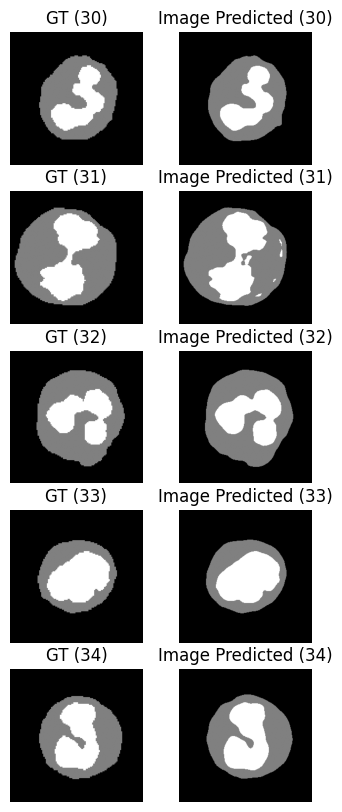

In [14]:
start_idx = 30
num_samples = 5

model = trained_model_3
titles = ["GT", "Image Predicted"]

fig, axes = plt.subplots(num_samples, 2, figsize=(4, 2 * num_samples))

for i in range(num_samples):
    idx = start_idx + i

    image = images_val[idx].unsqueeze(0)
    image_pred = model(image)[0].squeeze(0)
    mask = image_pred.argmax(dim=0)
    mask_np = mask.cpu().numpy()
    mask_vis = (mask_np * (255 // 2)).astype(np.uint8)
    mask_gt = masks_val[idx]
    
    mask_np_0 = mask_gt.cpu().numpy()
    mask_vis_0 = (mask_np_0 * (255 // 2)).astype(np.uint8)

    axes[i, 0].imshow(mask_vis_0, cmap='gray')
    axes[i, 0].set_title(f"{titles[0]} ({idx})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_vis, cmap='gray')
    axes[i, 1].set_title(f"{titles[1]} ({idx})")
    axes[i, 1].axis('off')

In [1]:
img_path = r"C:\Test-A\Neutrophil/95-8-17-1_125_2.jpg"
image = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
img_resized = transform(image).unsqueeze(0)  
pred = trained_model_2(img_resized)[0]
pred = pred.squeeze(0)
mask = pred.argmax(dim=0)
import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


NameError: name 'Image' is not defined

In [10]:
masks_img = trained_model_1(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)


import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


NameError: name 'image' is not defined

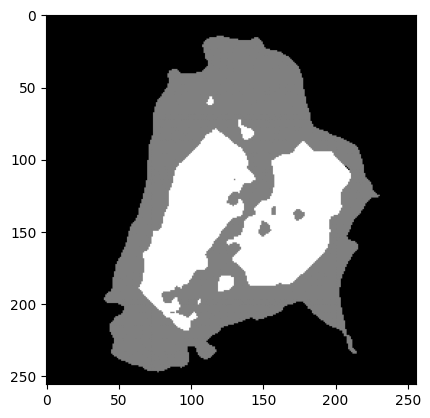

In [ ]:
masks_img = trained_model_15(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)

import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


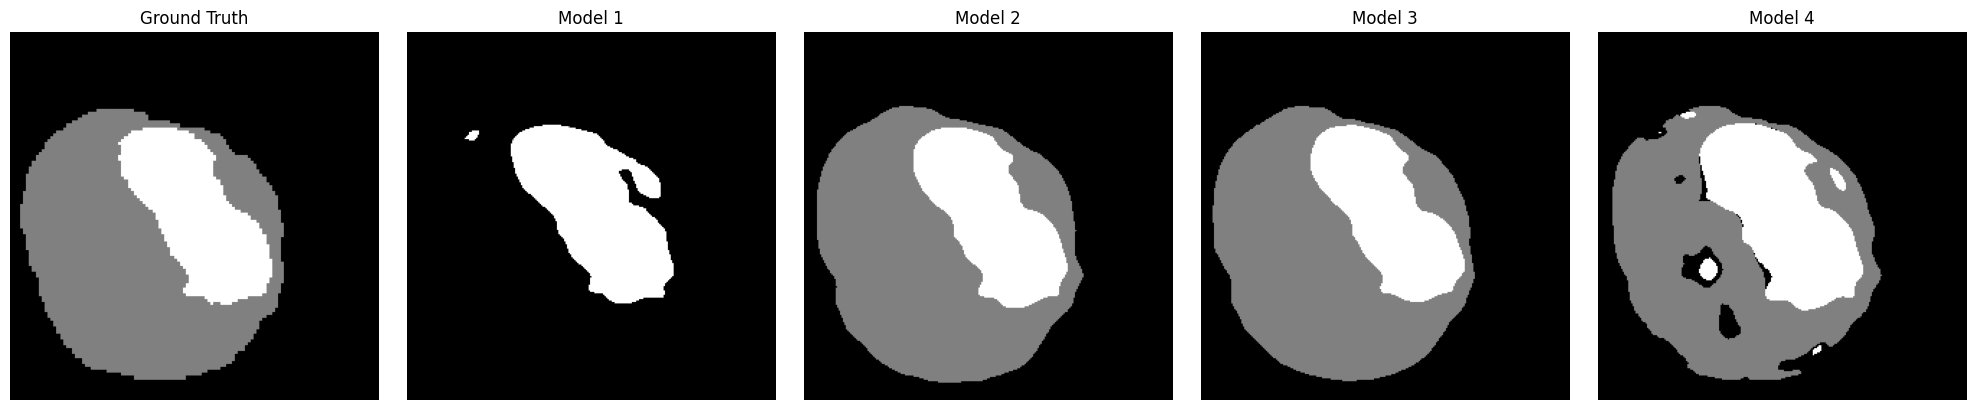

In [ ]:
masks_img_1 = trained_model_1(image)[0]
masks_img_2 = trained_model_2(image)[0]
masks_img_3 = trained_model_3(image)[0]
masks_img_4 = trained_model_4(image)[0]

pred_1 = masks_img_1.squeeze(0)
pred_2 = masks_img_2.squeeze(0)
pred_3 = masks_img_3.squeeze(0)
pred_4 = masks_img_4.squeeze(0)

mask_1 = pred_1.argmax(dim=0)
mask_2 = pred_2.argmax(dim=0)
mask_3 = pred_3.argmax(dim=0)
mask_4 = pred_4.argmax(dim=0)

# ===== Ground truth (FIX ở đây) =====
mask_0 = mask_img   # (H, W), không cần argmax

# ===== Convert numpy =====
mask_np_0 = mask_0.cpu().numpy()
mask_np_1 = mask_1.cpu().numpy()
mask_np_2 = mask_2.cpu().numpy()
mask_np_3 = mask_3.cpu().numpy()
mask_np_4 = mask_4.cpu().numpy()

# ===== Scale =====
mask_vis_0 = (mask_np_0 * (255 // 2)).astype(np.uint8)
mask_vis_1 = (mask_np_1 * (255 // 2)).astype(np.uint8)
mask_vis_2 = (mask_np_2 * (255 // 2)).astype(np.uint8)
mask_vis_3 = (mask_np_3 * (255 // 2)).astype(np.uint8)
mask_vis_4 = (mask_np_4 * (255 // 2)).astype(np.uint8)

# ===== Plot =====
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Ground Truth
axes[0].imshow(mask_vis_0, cmap='gray')
axes[0].set_title("Ground Truth")
axes[0].axis('off')

# Models
axes[1].imshow(mask_vis_1, cmap='gray')
axes[1].set_title("Model 1")
axes[1].axis('off')

axes[2].imshow(mask_vis_2, cmap='gray')
axes[2].set_title("Model 2")
axes[2].axis('off')

axes[3].imshow(mask_vis_3, cmap='gray')
axes[3].set_title("Model 3")
axes[3].axis('off')

axes[4].imshow(mask_vis_4, cmap='gray')
axes[4].set_title("Model 4")
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
iou = compute_iou(mask_1, mask_0)

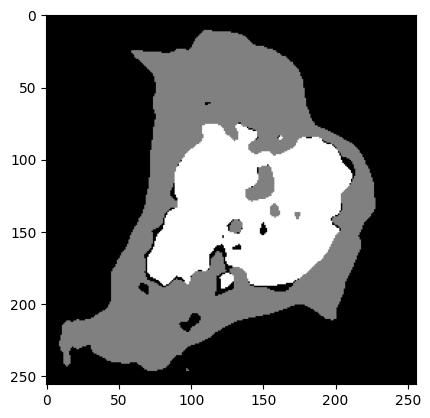

In [ ]:

masks_img = trained_model_25(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)

import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


In [ ]:
print(torch.unique(mask))
print(mask.mean(dim=(1,2)))

tensor([0, 1, 2])


RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long

In [ ]:
LEARNING_RATE = 2e-4
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 1
NUM_WORKERS = 4
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
PIN_MEMORY = True
LOAD_MODEL = False
WEIGHT_DECAY = 5e-5
weight_cross_entropy = 2
weight_mask = 5
weight_rec = 1


In [ ]:

def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)

def load_checkpoint(checkpoint, model):
    print("=> Loading checkpoint")
    model.load_state_dict(checkpoint["state_dict"])

def check_accuracy(loader,model,device="cuda"):
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    model.eval()
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = torch.sigmoid(model(x))
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)
    print(f"Got {num_correct}/{num_pixels} with acc {num_correct/num_pixels*100:.2f}")
    print(f"Dice score: {dice_score/len(loader)}")
    model.train()
    
def get_optimizer(model, reconstruction, learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY):

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(reconstruction.parameters()),
        lr=learning_rate,
        weight_decay=float(weight_decay),
        betas=(0.9, 0.999)
    )
    return optimizer

def get_scaler():

    scaler = torch.cuda.amp.GradScaler()
    return scaler

In [ ]:
from tqdm import tqdm

In [ ]:
def training_fn(loader, model, optimizer, CrossEntropyLoss,DICELoss,BCELoss, ReconstructionLoss, scaler):
    loop = tqdm(loader)
    
    for batch_idx in loop:
        images = batch["image"]
        masks = batch["mask"]
        binarys = batch["binary"]
        images = images.to(device=DEVICE)
        masks = masks.float().to(device=DEVICE)
        masks_long = masks.long().to(device=DEVICE)
        binarys = binarys.float().to(device=DEVICE)

        # forward
        with torch.cuda.amp.autocast():
            predictions, encoded_features, query_features = model(images)
            CrossEntropy = CrossEntropyLoss(predictions, masks_long)
            mask_loss = 0
            K = predictions.shape[1]
            for k in range(K):
                pred_binary  = predictions[:, k:k+1, :, :]
                target_binary = (masks == k).float()
                dice = DICELoss(pred_binary, target_binary.long())
                bce = BCELoss(pred_binary, target_binary.unsqueeze(1))
                mask_loss += bce + dice
            Reconstruction = ReconstructionLoss(encoded_features, query_features)
            loss = weight_cross_entropy * CrossEntropy + weight_mask * mask_loss + weight_rec * Reconstruction

        # backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update tqdm loop        
        loop.set_postfix(loss=loss.item())


In [ ]:
os.getcwd()

'd:\\work\\WBC_Segmentation'

In [ ]:
from WhiteBloodCellClassification.DomainAdaptation.DA_module import DomainAdaptationModule
from WhiteBloodCellClassification.models.losses import DiceLoss, BCELoss, ReconstructionLoss, CLSLoss

In [ ]:
model = DomainAdaptationModule().to(DEVICE)
CrossEntropyLoss = CLSLoss()
diceLoss = DiceLoss()
bceLoss = BCELoss()
reconstructionLoss = ReconstructionLoss()
optimizer = get_optimizer(model)
scaler = get_scaler()
training_fn(loader=dataloader, model=model, optimizer=optimizer, CrossEntropyLoss=CrossEntropyLoss, DICELoss=diceLoss, BCELoss=bceLoss, ReconstructionLoss=reconstructionLoss, scaler=scaler)

TypeError: get_optimizer() missing 1 required positional argument: 'reconstruction'

In [ ]:
model = DomainAdaptationModule().to(DEVICE)
for name, param in model.named_parameters():
    print(name, param.shape)

In [ ]:
class ReconstructionLoss(nn.Module):
    def __init__(self, encoder_dim=2048, query_dim=256, use_c3=True):
        super().__init__()
        self.use_c3 = use_c3
        
        self.reconstruction_mlp = nn.Sequential(
            nn.Linear(query_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(512, encoder_dim),
            nn.LayerNorm(encoder_dim)  # Thêm LayerNorm để ổn định
        )
        
        if use_c3:
            self.feature_proj = nn.Linear(1024, encoder_dim)
        else:
            self.feature_proj = None
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.reconstruction_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)  # Giảm gain
                nn.init.constant_(m.bias, 0.0)
        if self.feature_proj is not None:
            nn.init.xavier_uniform_(self.feature_proj.weight, gain=0.5)
            nn.init.constant_(self.feature_proj.bias, 0.0)
    
    def forward(self, encoder_features, query_features):
        # Lấy feature
        if self.use_c3:
            target_feature = encoder_features[2]  # c3: [B, 1024, H, W]
            g_i = target_feature.mean(dim=[2, 3])  # [B, 1024]
            g_i = self.feature_proj(g_i)  # [B, 2048]
        else:
            target_feature = encoder_features[3]  # c4: [B, 2048, H, W]
            g_i = target_feature.mean(dim=[2, 3])  # [B, 2048]
        
        # QUAN TRỌNG: Detach và không normalize ngay
        g_i = g_i.detach()
        
        # Lấy query 0
        g_hat = query_features[:, 0, :]  # [B, 256]
        g_hat = self.reconstruction_mlp(g_hat)  # [B, 2048]
        
        # ===== CÁCH TÍNH LOSS MỚI =====
        # Không normalize trước, tính loss trực tiếp
        
        # Option 1: MSE trên raw features (có scale)
        loss_raw = F.mse_loss(g_hat, g_i)
        
        # Option 2: Cosine similarity loss (chỉ quan tâm hướng)
        cos_sim = F.cosine_similarity(g_hat, g_i, dim=1).mean()
        loss_cos = 1 - cos_sim
        
        # Option 3: MSE trên normalized features (đúng công thức)
        g_i_norm = F.normalize(g_i, p=2, dim=1)
        g_hat_norm = F.normalize(g_hat, p=2, dim=1)
        loss_norm_mse = F.mse_loss(g_hat_norm, g_i_norm)
        
        # Debug
        with torch.no_grad():
            print(f"Loss raw (MSE): {loss_raw.item():.6f}")
            print(f"Loss cos (1 - cos): {loss_cos.item():.6f}")
            print(f"Loss norm MSE: {loss_norm_mse.item():.6f}")
            
            # Kiểm tra cosine similarity
            cos_sim_value = F.cosine_similarity(g_hat, g_i, dim=1).mean()
            print(f"Cosine similarity (raw): {cos_sim_value:.4f}")
            
            cos_sim_norm = F.cosine_similarity(g_i_norm, g_hat_norm, dim=1).mean()
            print(f"Cosine similarity (norm): {cos_sim_norm:.4f}")
        
        # Sử dụng loss_cos vì nó ổn định hơn
        return loss_cos * 0.5  # Weight 0.5

In [ ]:
# Test code
if __name__ == "__main__":
    # Tạo dummy features
    B, C, H, W = 2, 3, 256, 256
    
    # Giả lập encoder_features
    encoder_features = [
        torch.randn(B, 256, H//4, W//4),   # c1
        torch.randn(B, 512, H//8, W//8),   # c2
        torch.randn(B, 1024, H//16, W//16), # c3
        torch.randn(B, 2048, H//32, W//32)  # c4
    ]
    
    # Giả lập query_features
    num_queries = 32
    query_dim = 256
    query_features = torch.randn(B, num_queries, query_dim)
    
    # Test ReconstructionLoss
    rec_loss = ReconstructionLoss(encoder_dim=512, query_dim=256, use_c3=True)
    loss = rec_loss(encoder_features, query_features)
    
    print(f"\nFinal loss: {loss.item():.6f}")

Loss raw (MSE): 1.002888
Loss cos (1 - cos): 1.027537
Loss norm MSE: 0.004014
Cosine similarity (raw): -0.0275
Cosine similarity (norm): -0.0275

Final loss: 0.513768


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NuclearCytoplasmicClassifier(nn.Module):
    """
    Nuclear-cytoplasmic knowledge-aware classifier with DOWNSAMPLING strategy.
    
    This version downsamples segmentation maps to match encoder feature resolution,
    which is memory-efficient and fast while still preserving region-level information.
    
    Args:
        in_channels (int): Encoder feature channels (default: 2048 for ResNet c4)
        seg_classes (int): Number of segmentation classes (typically 2: nucleus, cytoplasm)
        num_classes (int): Number of WBC types to classify
        hidden_dim (int): MLP hidden dimension
        dropout (float): Dropout rate for regularization
        use_sigmoid (bool): Use sigmoid instead of softmax (recommended for overlapping regions)
    """
    def __init__(self, in_channels=2048, seg_classes=3, num_classes=6, 
                 hidden_dim=256, dropout=0.5, use_sigmoid=True):
        super().__init__()
        self.seg_classes = seg_classes
        self.use_sigmoid = use_sigmoid
        
        # Conv 1x1 to transform encoder features
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        
        # MLP classifier
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, f_j, z_hat, z_is_logits=True):
        """
        Args:
            f_j (Tensor): Encoder features (B, C, H_f, W_f) - e.g., (4, 2048, 8, 8)
            z_hat (Tensor): Segmentation map (B, K, H_z, W_z) - e.g., (4, 2, 224, 224)
            z_is_logits (bool): If True, apply sigmoid/softmax to z_hat
            
        Returns:
            logits (Tensor): Classification logits (B, num_classes)
        """
        B, C, H_f, W_f = f_j.shape
        _, K, H_z, W_z = z_hat.shape
        
        assert K == self.seg_classes, \
            f"Expected {self.seg_classes} seg classes, got {K}"
        
        # Step 1: Transform encoder features (keep original size)
        f_conv = self.conv(f_j)  # (B, C, H_f, W_f)
        
        # Step 2: DOWNSAMPLE z_hat to match f_j resolution
        z_down = F.interpolate(
            z_hat,
            size=(H_f, W_f),
            mode='bilinear',
            align_corners=False
        )  # (B, K, H_f, W_f)
        
        # Step 3: Convert segmentation logits to probabilities
        if z_is_logits:
            if self.use_sigmoid:
                # Sigmoid: each class independent (allows nucleus & cytoplasm overlap)
                z_prob = torch.sigmoid(z_down)  # (B, K, H_f, W_f)
            else:
                # Softmax: classes are mutually exclusive
                z_prob = torch.softmax(z_down, dim=1)  # (B, K, H_f, W_f)
        else:
            z_prob = z_down
        
        # Step 4: Weighted pooling - combine features with segmentation weights
        # (B, C, H_f, W_f) * (B, K, H_f, W_f) -> sum over spatial -> (B, K, C)
        class_features = torch.einsum('bchw,bkhw->bkc', f_conv, z_prob)
        
        # Step 5: Aggregate across classes
        aggregated = class_features.sum(dim=1)  # (B, C)
        
        # Step 6: Normalize by total weight to get weighted average
        total_weight = z_prob.sum(dim=(1, 2, 3)).unsqueeze(1)  # (B, 1)
        aggregated = aggregated / (total_weight + 1e-6)  # (B, C)
        
        # Step 7: Classify
        logits = self.mlp(aggregated)  # (B, num_classes)
        
        return logits

In [ ]:


classifier = NuclearCytoplasmicClassifier()

image = images_train
pred_image,feature,Qi = trained_model_1(image)
logit = classifier(feature[-1], pred_image)
print(logit)


tensor([[-0.5460, -0.1413,  0.5004,  0.1577, -0.3005, -0.4523],
        [-0.5653, -0.3834,  0.0815,  0.9041,  0.9068, -0.6313],
        [-0.3206, -0.4990,  0.4772, -0.0512,  0.1524,  0.4731],
        [-1.2697, -0.3009,  0.0620,  0.4175, -0.0402, -1.3709],
        [ 0.1290, -1.2339,  0.4834, -0.2278,  0.7138, -0.5716],
        [-0.5365, -0.0760, -0.0705, -0.6617, -0.4433, -0.5839],
        [-0.1857,  0.1045,  0.8032,  0.2576,  1.1156, -0.9747],
        [-0.1770, -0.3021,  0.7471, -0.3762,  0.3801, -0.5532]],
       grad_fn=<AddmmBackward0>)


In [ ]:

pred = logit.argmax(dim=1)
pred

tensor([2, 4, 2, 3, 4, 2, 4, 2])

: 

In [ ]:
from torchvision import datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
train_classification_dataset  = datasets.ImageFolder(root=r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/ClassificationData/PBC_dataset_split/Train", transform=transform)
train_classification_dataset

Dataset ImageFolder
    Number of datapoints: 32768
    Root location: D:\work\WBC_Segmentation\WhileBloodCellClassification\data/ClassificationData/PBC_dataset_split/Train
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )

In [ ]:
from torch.utils.data import DataLoader

train_classification_loader = DataLoader(train_classification_dataset, batch_size=32, shuffle=True)
train_classification_loader

In [ ]:
for images, labels in train_classification_loader:
    print(images.shape, labels.shape)
    break

torch.Size([32, 3, 256, 256]) torch.Size([32])


In [ ]:
from tqdm import tqdm

loop = tqdm(train_classification_loader)
print(len(loop))


  0%|          | 0/1024 [00:00<?, ?it/s]

1024


In [ ]:
labels

In [ ]:
class ClassificationLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,y_hat,y):
        prob = torch.softmax(y_hat, dim=1)
        log_probs = torch.log(prob + 1e-8)
        loss = -(y * log_probs).sum(dim=1).mean()
        return loss

In [ ]:
def classification_training(loader,model,optimizer,scaler,ClassificationLoss):
   loop = tqdm(loader)
   total_loss = 0

   for batch in loop:
        images, labels = batch
        images = images.to(device=DEVICE)
        labels = labels.to(device=DEVICE)
        with torch.cuda.amp.autocast():
            predictions = model(images)
            loss = ClassificationLoss(predictions, F.one_hot(labels, num_classes=8).float())
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    

In [ ]:
from WhiteBloodCellClassification.DomainAdaptation.DA_module import DomainAdaptationModule


model = DomainAdaptationModule()
print("=== Model Structure ===")
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

d:\work\WBC_Segmentation\WhileBloodCellClassification\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\work\WBC_Segmentation\WhileBloodCellClassification\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== Model Structure ===
pixel_encoder.conv1.weight: torch.Size([64, 3, 7, 7])
pixel_encoder.bn1.weight: torch.Size([64])
pixel_encoder.bn1.bias: torch.Size([64])
pixel_encoder.layer1.0.conv1.weight: torch.Size([64, 64, 1, 1])
pixel_encoder.layer1.0.bn1.weight: torch.Size([64])
pixel_encoder.layer1.0.bn1.bias: torch.Size([64])
pixel_encoder.layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
pixel_encoder.layer1.0.bn2.weight: torch.Size([64])
pixel_encoder.layer1.0.bn2.bias: torch.Size([64])
pixel_encoder.layer1.0.conv3.weight: torch.Size([256, 64, 1, 1])
pixel_encoder.layer1.0.bn3.weight: torch.Size([256])
pixel_encoder.layer1.0.bn3.bias: torch.Size([256])
pixel_encoder.layer1.0.downsample.0.weight: torch.Size([256, 64, 1, 1])
pixel_encoder.layer1.0.downsample.1.weight: torch.Size([256])
pixel_encoder.layer1.0.downsample.1.bias: torch.Size([256])
pixel_encoder.layer1.1.conv1.weight: torch.Size([64, 256, 1, 1])
pixel_encoder.layer1.1.bn1.weight: torch.Size([64])
pixel_encoder.layer1.1.bn1

In [14]:
import random
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

def transform(image, mask):
    # Flip
    if random.random() > 0.5:
        image = TF.hflip(image)
        mask = TF.hflip(mask)
    
    # Rotation (giữ nguyên kích thước, không cắt)
    angle = random.uniform(-15, 15)
    image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, expand=False)
    mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, expand=False)
    
    # Color adjustment
    if random.random() > 0.5:
        image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
    if random.random() > 0.5:
        image = TF.adjust_contrast(image, random.uniform(0.8, 1.2))
    if random.random() > 0.5:
        image = TF.adjust_saturation(image, random.uniform(0.8, 1.2))
    
    return image, mask

In [15]:
class JSTCDataset(Dataset):
    def __init__(self,root_dir,mask_dir,transforms = transform,indices=None,  augment=True):
        self.mask_dir = os.path.join(root_dir, mask_dir)
        self.transforms = transform
        self.indices = indices
        self.augment = augment
        # self.binary_dir = os.path.join(root_dir, binary_dir)
        self.images = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.bmp')])
        self.mask = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.png')])
        # self.binary = sorted([f for f in os.listdir(self.binary_dir) if f.endswith('.png')])
        assert len(self.images) == len(self.mask), "Số lượng image và mask không khớp!"

    
    def __len__(self):
        if self.indices is not None:
            return len(self.indices)
        return len(self.images)
    def __getitem__(self, idx):
        if self.indices is not None:
            idx = self.indices[idx]
        img_name = self.images[idx]
        mask_name = self.mask[idx]
        # binary_name = self.binary[idx]
        img_path = os.path.join(self.mask_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        # binary_path = os.path.join(self.binary_dir, binary_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        # image = self.transforms(image)
        mask = cv2.imread(mask_path,0)
        mask = Image.fromarray(mask)
        image = TF.resize(image, (256, 256), interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (256, 256), interpolation=InterpolationMode.NEAREST)
        if self.augment and self.transforms is not None:
            image, mask = self.transforms(image, mask)
        # mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        image = TF.to_tensor(image)
        mask = np.array(mask)
        label_mask = np.zeros_like(mask)
        label_mask[mask == 255] = 2
        label_mask[mask == 128] = 1
        label_mask[mask == 0] = 0
        label_mask = torch.tensor(label_mask).long()
        # binary = cv2.imread(binary_path,0)
        # binary = cv2.resize(binary, (256, 256), interpolation=cv2.INTER_NEAREST)
        # label_binary = np.zeros_like(binary)
        # label_binary[binary == 255] = 1
        # label_binary[binary == 0] = 0
        # label_binary = torch.tensor(label_binary).long()
        return {
            "image": image,
            "mask": label_mask,
        }

In [16]:
root_dir = r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/SourceData"
mask_dir = r"Dataset"

In [22]:
np.random.seed(146)
fulldataset = JSTCDataset(root_dir, mask_dir)
num_samples = len(fulldataset)
indices = np.arange(num_samples)
np.random.shuffle(indices)
split = int(0.8 * num_samples)

train_indices = indices[:split]
val_indices = indices[split:]
train_dataset = JSTCDataset(root_dir, mask_dir, indices=train_indices, augment=True)
val_dataset   = JSTCDataset(root_dir, mask_dir, indices=val_indices, augment=False)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
for batch in train_loader:
    images_train = batch["image"]
    masks_train = batch["mask"]
    print(images_train.shape, masks_train.shape)
    break
for batch in val_loader:
    images_val = batch["image"]
    masks_val = batch["mask"]
    print(images_val.shape, masks_val.shape)
    break

torch.Size([16, 3, 256, 256]) torch.Size([16, 256, 256])
torch.Size([16, 3, 256, 256]) torch.Size([16, 256, 256])


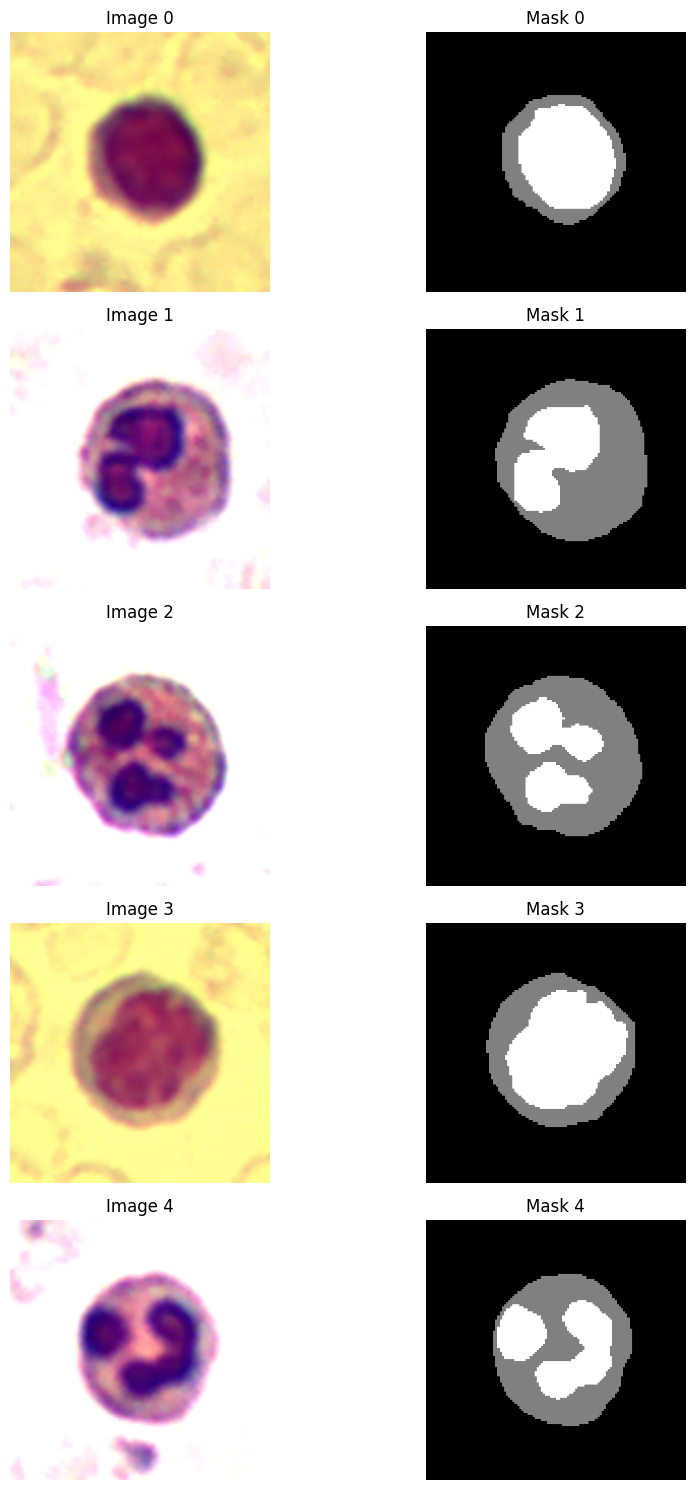

In [23]:
import matplotlib.pyplot as plt

images_train = batch["image"]
masks_train = batch["mask"]

num = 5
plt.figure(figsize=(10, num * 3))

for i in range(num):
    # tensor -> numpy
    image = images_train[i].permute(1, 2, 0).cpu().numpy()
    mask = masks_train[i].cpu().numpy()

    # plot image
    plt.subplot(num, 2, i * 2 + 1)
    plt.imshow(image)
    plt.title(f"Image {i}")
    plt.axis("off")

    # plot mask
    plt.subplot(num, 2, i * 2 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()